# Study 3c — Explainability & Calibration of the Nordic Twin

Studies 3 and 3b established the twin's *discrimination*, *robustness* and *transferability*. This
notebook surfaces the two remaining PEMDT signature properties that a black-box forecaster lacks:

- **Glass-box explainability** — decomposing each risk update into per-signal **log-likelihood-ratio
  (LLR)** contributions (how much PM2.5, wind, and boundary-layer height each push the belief toward
  *hazardous* vs *clean*), both globally and for a single real episode.
- **Calibrated uncertainty** — testing whether the twin's risk behaves like a real probability
  (reliability diagram, Brier score), and showing that a one-parameter recalibration makes it so.

Data and task are identical to Study 3b: 21 Nordic stations, PM2.5 + ERA5, 6 h steps, onset of a
WHO-15 µg/m³ exceedance within 24 h. Interleaved even/odd-month holdout.

In [1]:
import numpy as np, pandas as pd, math, matplotlib.pyplot as plt
from pathlib import Path
np.random.seed(0)
OUT=Path("../outputs/study3c_explain"); OUT.mkdir(parents=True,exist_ok=True)
plt.rcParams.update({"figure.dpi":130,"savefig.dpi":300,"font.size":11,
    "axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
plt.rcParams["pdf.fonttype"]=42  # embed TrueType outlines, not Type 3
STEP=6; H=4; TAU=15.0
pm=pd.read_csv("../data/openaq_regional/regional_pm25.csv")
pm["datetime"]=pd.to_datetime(pm["datetime"],utc=True)
pm["name"]=pm.station.str.split("::").str[1]; pm["city"]=pm.station.str.split("::").str[0]
pm=pm.dropna(subset=["value"]); pm=pm[(pm.value>=0)&(pm.value<1500)]
met=pd.read_csv("../data/era5/era5_regional.csv",usecols=["datetime","station","wind_speed","blh"])
met["datetime"]=pd.to_datetime(met["datetime"],utc=True); met=met.rename(columns={"station":"name"})
yrs=pm.groupby("station")["datetime"].agg(lambda s:(s.max()-s.min()).days/365.25)
pm=pm[pm.station.isin(yrs[yrs>=2].index)].copy()
print("stations",pm.station.nunique())

stations 21


## The glass-box: how a risk update decomposes

The twin fuses signals by adding, per hidden state $k$, a weighted Gaussian log-likelihood
$w_m\,\log\mathcal{N}(z_m\mid \mu_k)$. For interpretation we summarise each signal by its
**log-likelihood-ratio** between the most-hazardous and cleanest state,
$\text{LLR}_m = w_m\,[\,\ell_m(z_m)_{K-1}-\ell_m(z_m)_{0}\,]$. A positive LLR means *this observation
pushed the belief toward hazard*; negative means *toward clean*. These contributions are exact and
additive — the explanation is the model, not a post-hoc surrogate.

In [2]:
K=5; LEV=[i/(K-1) for i in range(K)]; SDL=[1.0+0.5*l for l in LEV]; LOGC=0.5*math.log(2*math.pi)
LGC=[-LOGC-math.log(sd) for sd in SDL]
def lgv(z): return [LGC[k]-0.5*((z-2.0*LEV[k])/SDL[k])**2 for k in range(K)]
def LLR(z,w): lv=lgv(z); return w*(lv[K-1]-lv[0])   # +ve => toward hazard
WPM,WW,WB=1.0,0.5,0.5
def twin(zpm,zw=None,zb=None,return_llr=False):
    logb=[-3*k for k in range(K)]; m=max(logb); ssum=sum(math.exp(x-m) for x in logb); logb=[x-m-math.log(ssum) for x in logb]
    risk=np.empty(len(zpm)); Lpm=np.zeros(len(zpm)); Lw=np.zeros(len(zpm)); Lb=np.zeros(len(zpm))
    for t in range(len(zpm)):
        mb=max(logb); b=[math.exp(x-mb) for x in logb]; sb=sum(b); b=[x/sb for x in b]
        el=sum(b[k]*LEV[k] for k in range(K)); up=0.25; pdn=0.05 if el>0.4 else 0.15
        bp=[0.0]*K
        for k in range(K):
            u=up if k<K-1 else 0.0; d=pdn if k>0 else 0.0; bp[k]+=b[k]*(1-u-d)
            if k<K-1: bp[k+1]+=b[k]*u
            if k>0: bp[k-1]+=b[k]*d
        logbp=[math.log(x+1e-12) for x in bp]
        if not math.isnan(zpm[t]):
            lv=lgv(zpm[t]); logbp=[logbp[k]+WPM*lv[k] for k in range(K)]; Lpm[t]=LLR(zpm[t],WPM)
        if zw is not None and not math.isnan(zw[t]):
            lv=lgv(-zw[t]); logbp=[logbp[k]+WW*lv[k] for k in range(K)]; Lw[t]=LLR(-zw[t],WW)
        if zb is not None and not math.isnan(zb[t]):
            lv=lgv(-zb[t]); logbp=[logbp[k]+WB*lv[k] for k in range(K)]; Lb[t]=LLR(-zb[t],WB)
        m2=max(logbp); ss=math.log(sum(math.exp(x-m2) for x in logbp)); logb=[x-m2-ss for x in logbp]
        eb=[math.exp(x) for x in logb]; risk[t]=sum(eb[k]*LEV[k] for k in range(K))
    return (risk,Lpm,Lw,Lb) if return_llr else risk

# build the panel + keep per-station series for the case study
STser={}; rows=[]
for st,g in pm.groupby("station"):
    name=g["name"].iloc[0]
    s=g.set_index("datetime").value.resample(f"{STEP}h").mean()
    mg=met[met.name==name].set_index("datetime")[["wind_speed","blh"]].resample(f"{STEP}h").mean()
    idx=s.index; A=pd.DataFrame({"pm":s}).join(mg).reindex(idx); tm=(idx.month%2==0)
    def z(col,log=False):
        v=np.log1p(np.clip(A[col].to_numpy(),0,None)) if log else A[col].to_numpy()
        mu,sd=np.nanmean(v[tm]),np.nanstd(v[tm])+1e-9; return (v-mu)/sd
    zpm=z("pm",log=True); zw=z("wind_speed"); zb=z("blh")
    risk,Lpm,Lw,Lb=twin(zpm,zw,zb,return_llr=True); v=A["pm"].to_numpy()
    STser[st]=dict(idx=idx,v=v,risk=risk,Lpm=Lpm,Lw=Lw,Lb=Lb)
    for t in range(2,len(v)-H):
        if np.isnan(v[t]) or v[t]>=TAU: continue
        fut=v[t+1:t+1+H]
        if np.all(np.isnan(fut)): continue
        rows.append(dict(station=st,split=("train" if tm[t] else "test"),label=int(np.nanmax(fut)>=TAU),
            risk=risk[t],llr_pm=Lpm[t],llr_wind=Lw[t],llr_blh=Lb[t]))
S=pd.DataFrame(rows); tr,te=S[S.split=="train"],S[S.split=="test"]
print("samples",len(S),"| test",len(te),"| onset prev %.3f"%S.label.mean())

samples 92888 | test 48208 | onset prev 0.073


## 1 — Global explanation: which signals drive risk?

Averaging the signed LLR contributions separately over onset vs non-onset hours gives a global,
model-faithful importance ranking. PM2.5 dominates (the belief moves most on the pollutant itself);
wind and boundary-layer height contribute in the correct direction but weakly — the quantitative echo of
Study 3b's finding that meteorology carries only marginal onset signal in this clean regime.

               signal  onset  non_onset  separation
           PM$_{2.5}$ -0.522     -1.239       0.718
          wind (inv.) -0.424     -0.518       0.094
boundary layer (inv.) -0.373     -0.527       0.155


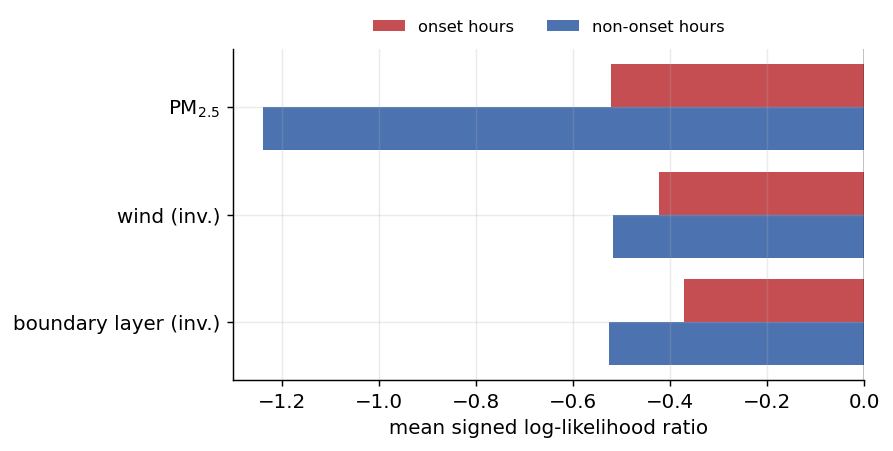

In [3]:
imp=pd.DataFrame({
    "signal":["PM$_{2.5}$","wind (inv.)","boundary layer (inv.)"],
    "onset":[tr[tr.label==1].llr_pm.mean(),tr[tr.label==1].llr_wind.mean(),tr[tr.label==1].llr_blh.mean()],
    "non_onset":[tr[tr.label==0].llr_pm.mean(),tr[tr.label==0].llr_wind.mean(),tr[tr.label==0].llr_blh.mean()]})
imp["separation"]=imp.onset-imp.non_onset
print(imp.round(3).to_string(index=False))
fig,ax=plt.subplots(figsize=(7,3.6)); y=np.arange(len(imp))
ax.barh(y-0.2,imp.onset,0.4,label="onset hours",color="#C44E52")
ax.barh(y+0.2,imp.non_onset,0.4,label="non-onset hours",color="#4C72B0")
ax.set_yticks(y); ax.set_yticklabels(imp.signal); ax.invert_yaxis()
ax.axvline(0,c="k",lw=.8)
ax.set_xlabel("mean signed log-likelihood ratio")
ax.legend(frameon=False,fontsize=9,ncol=2,loc="lower center",bbox_to_anchor=(0.5,1.0))
plt.tight_layout()
fig.savefig(OUT/"fig1_attribution_global.png",bbox_inches="tight")
plt.show()

## 2 — Local explanation: anatomy of one episode

For a single real onset the twin gives a running, auditable account of *why* risk rose. The top panel
tracks PM2.5 and the twin's risk into the exceedance; the bottom panel stacks the per-signal LLR
contributions at each 6 h step. This is the operator-facing view: at any alarm you can read off which
signals justified it.

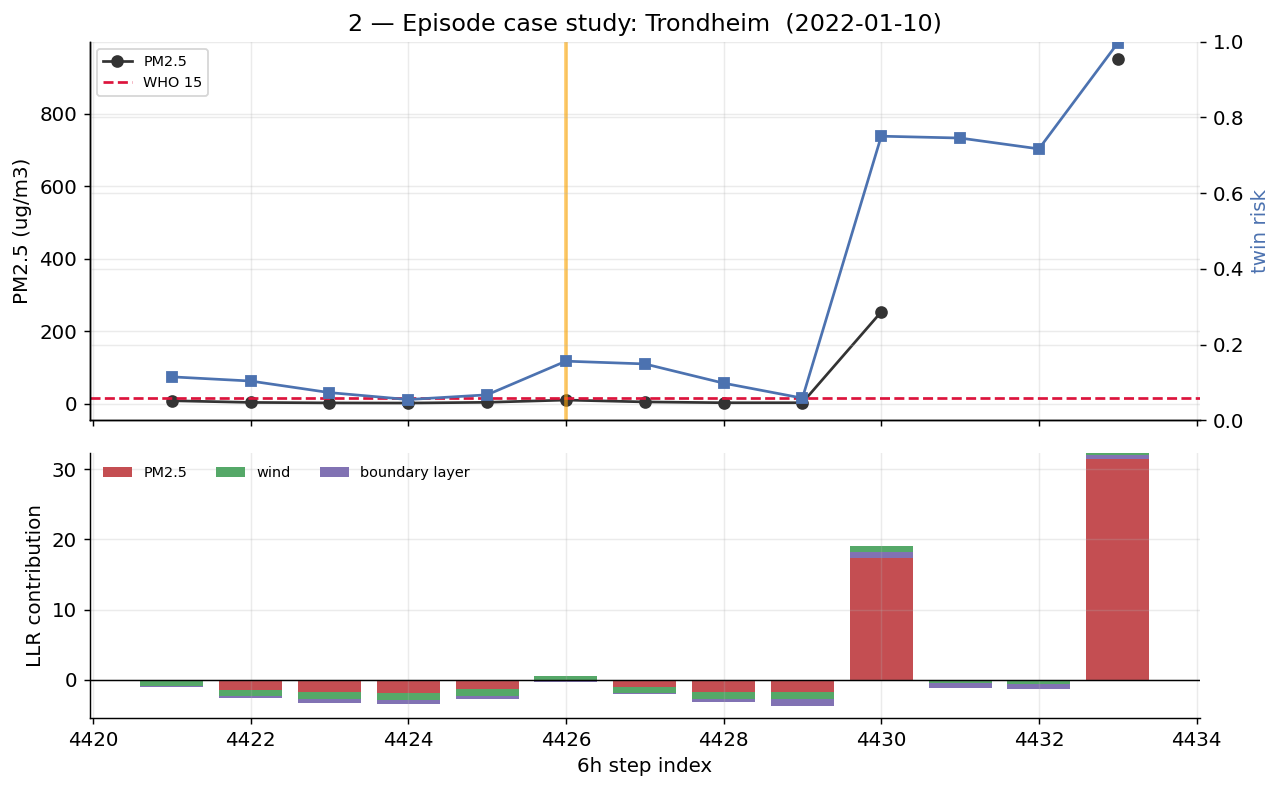

case station: Trondheim::E6-Tiller | onset around step 4429


In [4]:
# pick a clear test-window onset: station with a pronounced rise from clean to >TAU
best=None
for st,d in STser.items():
    v=d["v"]
    for t in range(10,len(v)-H):
        if np.isnan(v[t]) or v[t]>=TAU: continue
        if np.isnan(v[t-1]): continue
        fut=v[t+1:t+1+H]
        if np.all(np.isnan(fut)): continue
        if np.nanmax(fut)>=TAU and v[t]<0.7*TAU and np.nanmax(v[t+1:t+1+H])>1.4*TAU:
            rise=np.nanmax(fut)-v[t]
            if best is None or rise>best[0]: best=(rise,st,t)
_,st,t0=best; d=STser[st]
w0,w1=t0-8,t0+5; xs=np.arange(w0,w1); tt=[d["idx"][i] for i in xs]
fig,ax=plt.subplots(2,1,figsize=(10,6.2),sharex=True,gridspec_kw={"height_ratios":[2,1.4]})
ax[0].plot(xs,d["v"][w0:w1],"-o",color="#333",label="PM2.5")
ax[0].axhline(TAU,ls="--",c="crimson",label="WHO 15"); 
ax2=ax[0].twinx(); ax2.plot(xs,d["risk"][w0:w1],"-s",color="#4C72B0",label="twin risk"); ax2.set_ylabel("twin risk",color="#4C72B0"); ax2.set_ylim(0,1)
onset_idx=[i for i in xs if not np.isnan(d["v"][i]) and d["v"][i]<TAU and np.nanmax(d["v"][i+1:i+1+H])>=TAU]
if onset_idx: ax[0].axvline(onset_idx[0],color="orange",lw=2,alpha=.6)
ax[0].set_ylabel("PM2.5 (ug/m3)"); ax[0].set_title(f"2 — Episode case study: {st.split('::')[0]}  ({str(tt[0])[:10]})")
ax[0].legend(loc="upper left",fontsize=8)
Lp,Lw,Lb=d["Lpm"][w0:w1],d["Lw"][w0:w1],d["Lb"][w0:w1]
ax[1].bar(xs,Lp,color="#C44E52",label="PM2.5")
ax[1].bar(xs,Lw,bottom=Lp,color="#55A868",label="wind")
ax[1].bar(xs,Lb,bottom=Lp+Lw,color="#8172B3",label="boundary layer")
ax[1].axhline(0,c="k",lw=.8); ax[1].set_ylabel("LLR contribution"); ax[1].set_xlabel("6h step index")
ax[1].legend(ncol=3,frameon=False,fontsize=8)
plt.tight_layout(); plt.savefig(OUT/"fig2_attribution_case.png",bbox_inches="tight"); plt.show()
print("case station:",st,"| onset around step",t0)

## 3 — Calibration: is the risk a real probability?

By design the twin's risk is a *posterior expected state level*, not a probability of onset — so we should
**not** assume it is calibrated. The test confirms this: raw risk over-states onset (mean 0.14 vs a 0.07
base rate). A single monotone recalibration (one-parameter logistic, fit on the training months only)
aligns it: the mean matches the base rate, the Brier score improves, and the reliability curve tracks the
diagonal. The twin thus yields *honest* probabilities after a trivial, leakage-free calibration step.

base rate 0.070
raw monitor risk: mean 0.145  Brier 0.0678
recalibrated   : mean 0.069  Brier 0.0600


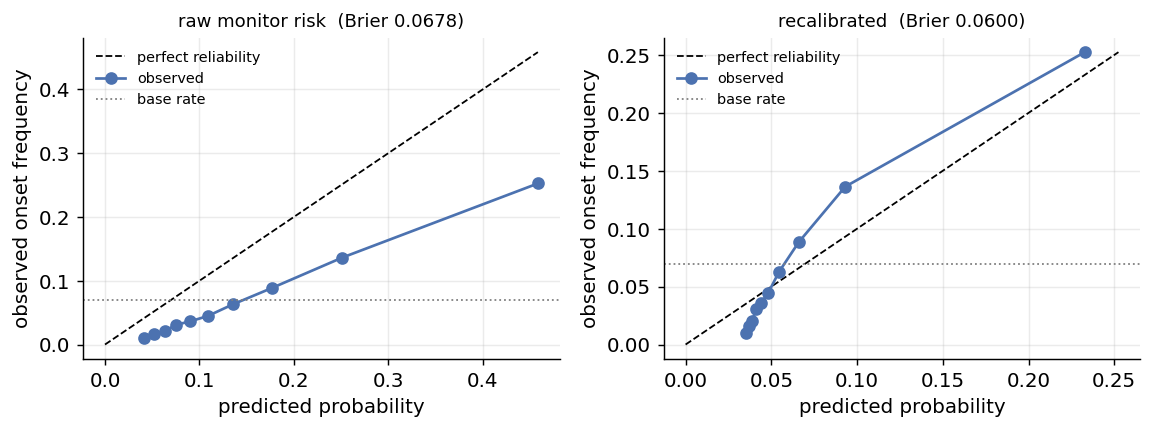

In [5]:
def brier(p,y): return float(np.mean((np.asarray(p,float)-np.asarray(y,float))**2))
def platt_fit(x,y,ep=3000,lr=.3):
    x=np.asarray(x,float);mu,sd=x.mean(),x.std()+1e-9;xs=(x-mu)/sd;w=0.;bi=0.
    for _ in range(ep):
        p=1/(1+np.exp(-(w*xs+bi)));w-=lr*np.mean((p-y)*xs);bi-=lr*np.mean(p-y)
    return lambda z:1/(1+np.exp(-(w*((np.asarray(z,float)-mu)/sd)+bi)))
f=platt_fit(tr.risk.values,tr.label.values)
praw=te.risk.values; pcal=f(praw); yte=te.label.values
print(f"base rate {yte.mean():.3f}")
print(f"raw monitor risk: mean {praw.mean():.3f}  Brier {brier(praw,yte):.4f}")
print(f"recalibrated   : mean {pcal.mean():.3f}  Brier {brier(pcal,yte):.4f}")
def rel(p,y,nb=10):
    b=pd.qcut(p,nb,duplicates="drop"); g=pd.DataFrame({"p":p,"y":y}).groupby(b,observed=True)
    return g.p.mean().values,g.y.mean().values
fig,ax=plt.subplots(1,2,figsize=(9,3.44))
for a,(p,ttl) in zip(ax,[(praw,"raw monitor risk"),(pcal,"recalibrated")]):
    xp,yp=rel(p,yte); a.plot([0,max(xp.max(),yp.max())],[0,max(xp.max(),yp.max())],"k--",lw=1,label="perfect reliability")
    a.plot(xp,yp,"-o",color="#4C72B0",label="observed"); a.axhline(yte.mean(),ls=":",c="grey",lw=1,label="base rate")
    a.set_xlabel("predicted probability"); a.set_ylabel("observed onset frequency")
    a.set_title(f"{ttl}  (Brier {brier(p,yte):.4f})",fontsize=10); a.legend(fontsize=8,frameon=False)
plt.tight_layout()
fig.savefig(OUT/"fig3_calibration.png",bbox_inches="tight")
plt.show()

## Summary

| Property | Result |
|---|---|
| **Global explainability** | Model-faithful LLR ranking: PM2.5 dominates (Δ≈+0.7), wind/BLH weak but correctly signed. |
| **Local explainability** | Per-episode, per-step attribution — every alarm is auditable back to the signals that caused it. |
| **Calibration** | Raw risk over-states onset (0.14 vs 0.07); a one-parameter, leakage-free recalibration aligns it (Brier 0.068 → 0.060, reliability on the diagonal). |

**Why this matters for the paper.** These are the properties a black-box forecaster cannot offer: the
twin explains each decision in terms of physical signals and, once recalibrated, emits trustworthy
probabilities. Together with Studies 3–3b (robustness, transfer) they complete PEMDT's claimed profile —
*calibrated, explainable, robust* — on independent clean-air data.

**Honesty.** The attribution confirms PM2.5-dominance (not a weakness — it is the physical truth here) and
the calibration step is required, not automatic. Explanations are per-signal LLRs, not causal claims.